In [1]:
import ROOT
import numpy as np

f = ROOT.TFile.Open("/home/dsalma/damicm-ml/simulation/CCDSensor_PV_55a26z1_500_s0.root")
f.ls()

TFile**		/home/dsalma/damicm-ml/simulation/CCDSensor_PV_55a26z1_500_s0.root	
 TFile*		/home/dsalma/damicm-ml/simulation/CCDSensor_PV_55a26z1_500_s0.root	
  KEY: TTree	RunInfo;1	RunInfo
  KEY: TTree	CCDOut;1	CCDOut
  KEY: TTree	EventOut;1	EventOut
  KEY: TTree	PartInfo;1	particle info
  KEY: TTree	TrackOut;1	TrackOut


In [2]:
t = f.Get("CCDOut")

In [3]:
type(t)

<class cppyy.gbl.TTree at 0x5d37b65e27b0>

In [4]:
branches = t.GetListOfBranches()
print("Nbranches =", branches.GetEntries())

for i in range(branches.GetEntries()):
    b = branches.At(i)
    print(i, b.GetName())

Nbranches = 14
0 EventID
1 pdg
2 trackid
3 parentid
4 CCDid
5 posx
6 posy
7 posz
8 gposx
9 gposy
10 gposz
11 Edep
12 time
13 local_time


In [5]:
t.Print()


******************************************************************************
*Tree    :CCDOut    : CCDOut                                                 *
*Entries :      500 : Total =         2490281 bytes  File  Size =    1395158 *
*        :          : Tree compression factor =   1.78                       *
******************************************************************************
*Br    0 :EventID   : Int_t CCDOut                                           *
*Entries :      500 : Total  Size=       4662 bytes  One basket in memory    *
*Baskets :        0 : Basket Size=      32000 bytes  Compression=   1.00     *
*............................................................................*
*Br    1 :pdg       : vector<int> CCDOut                                     *
*Entries :      500 : Total  Size=     116056 bytes  File Size  =       5098 *
*Baskets :        3 : Basket Size=      32000 bytes  Compression=  19.11     *
*...................................................

In [6]:
t.GetEntry(10)
print(t.posx)
print(t.posy)
print(t.Edep)

{ 15.863591, 15.863591, 15.863591, 15.863591, 15.863587, 15.863586, 15.863589, 15.863590, 15.863589, 15.863591, 15.863599, 15.863609, 15.863597, 15.863592, 15.863603, 15.863635, 15.863635, 15.863635, 15.863636, 15.863636, 15.863635, 15.863635, 15.863635, 15.863635, 15.863634, 15.863630, 15.863630, 15.863616, 15.863606, 15.863604, 15.863591, 15.863589, 15.863588, 15.863585, 15.863572, 15.863547, 15.863536, 15.863520, 15.863520, 15.863520, 15.863512, 15.863512, 15.863516, 15.863517, 15.863522, 15.863523, 15.863523, 15.863523, 15.863530, 15.863533, 15.863558, 15.863557, 15.863571, 15.860745, 15.860746, 15.860745, 15.860743, 15.860742, 15.860743, 15.860742 }
{ 62.151771, 62.151771, 62.151771, 62.151796, 62.151799, 62.151798, 62.151800, 62.151801, 62.151802, 62.151792, 62.151786, 62.151781, 62.151777, 62.151773, 62.151836, 62.151852, 62.151853, 62.151848, 62.151845, 62.151845, 62.151845, 62.151849, 62.151849, 62.151850, 62.151853, 62.151855, 62.151849, 62.151854, 62.151856, 62.151856, 62.15

In [7]:
t.GetEntry(5)
print(type(t.posx))
print(len(t.posx))

<class cppyy.gbl.std.vector<double> at 0x5d37b22393a0>
71


ix = int(posx / pixel_size_x)
iy = int(posy / pixel_size_y)

image[iy, ix] += Edep / 3.74

diego suggestion of what the code will look like

In [16]:

pixel_size = 0.015  # mm
nx, ny = 6000, 1500

In [17]:
count = 0
for i in range(t.GetEntries()):
    t.GetEntry(i)
    for j in range(t.posx.size()):
        ix = int(round(t.posy[j] / pixel_size))
        iy = int(round(t.posx[j] / pixel_size))
        if 0 <= ix < nx and 0 <= iy < ny:
            count += 1

print(count)

27039


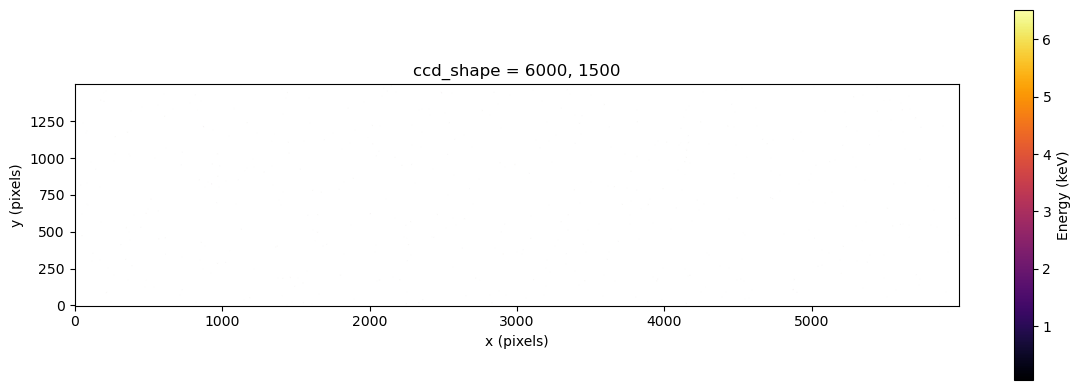

In [18]:
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((ny, nx))
# print("Number of entries:", t.GetEntries())
for i in range(t.GetEntries()):
    t.GetEntry(i)
    current_entry_posx = t.posx
    current_entry_posy = t.posy
    current_entry_Edep = t.Edep
    # print(len(current_entry_posx))
    # print(len(current_entry_posy))
    # print(len(current_entry_Edep))
    
    for j in range(current_entry_posx.size()):
        posx = current_entry_posx[j]
        posy = current_entry_posy[j]
        edep = current_entry_Edep[j]
        
        ix = int(posy / pixel_size)
        iy = int(posx / pixel_size)
        image[iy, ix] += edep / 1000

image_masked = np.ma.masked_where(image == 0, image)

plt.figure(figsize=(12, 4))
cmap = plt.cm.inferno.copy()
cmap.set_bad(color='white')
plt.imshow(image_masked, origin='lower', cmap=cmap, aspect='equal')
plt.colorbar(label='Energy (keV)')
plt.title('ccd_shape = 6000, 1500')
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.tight_layout()
plt.show()

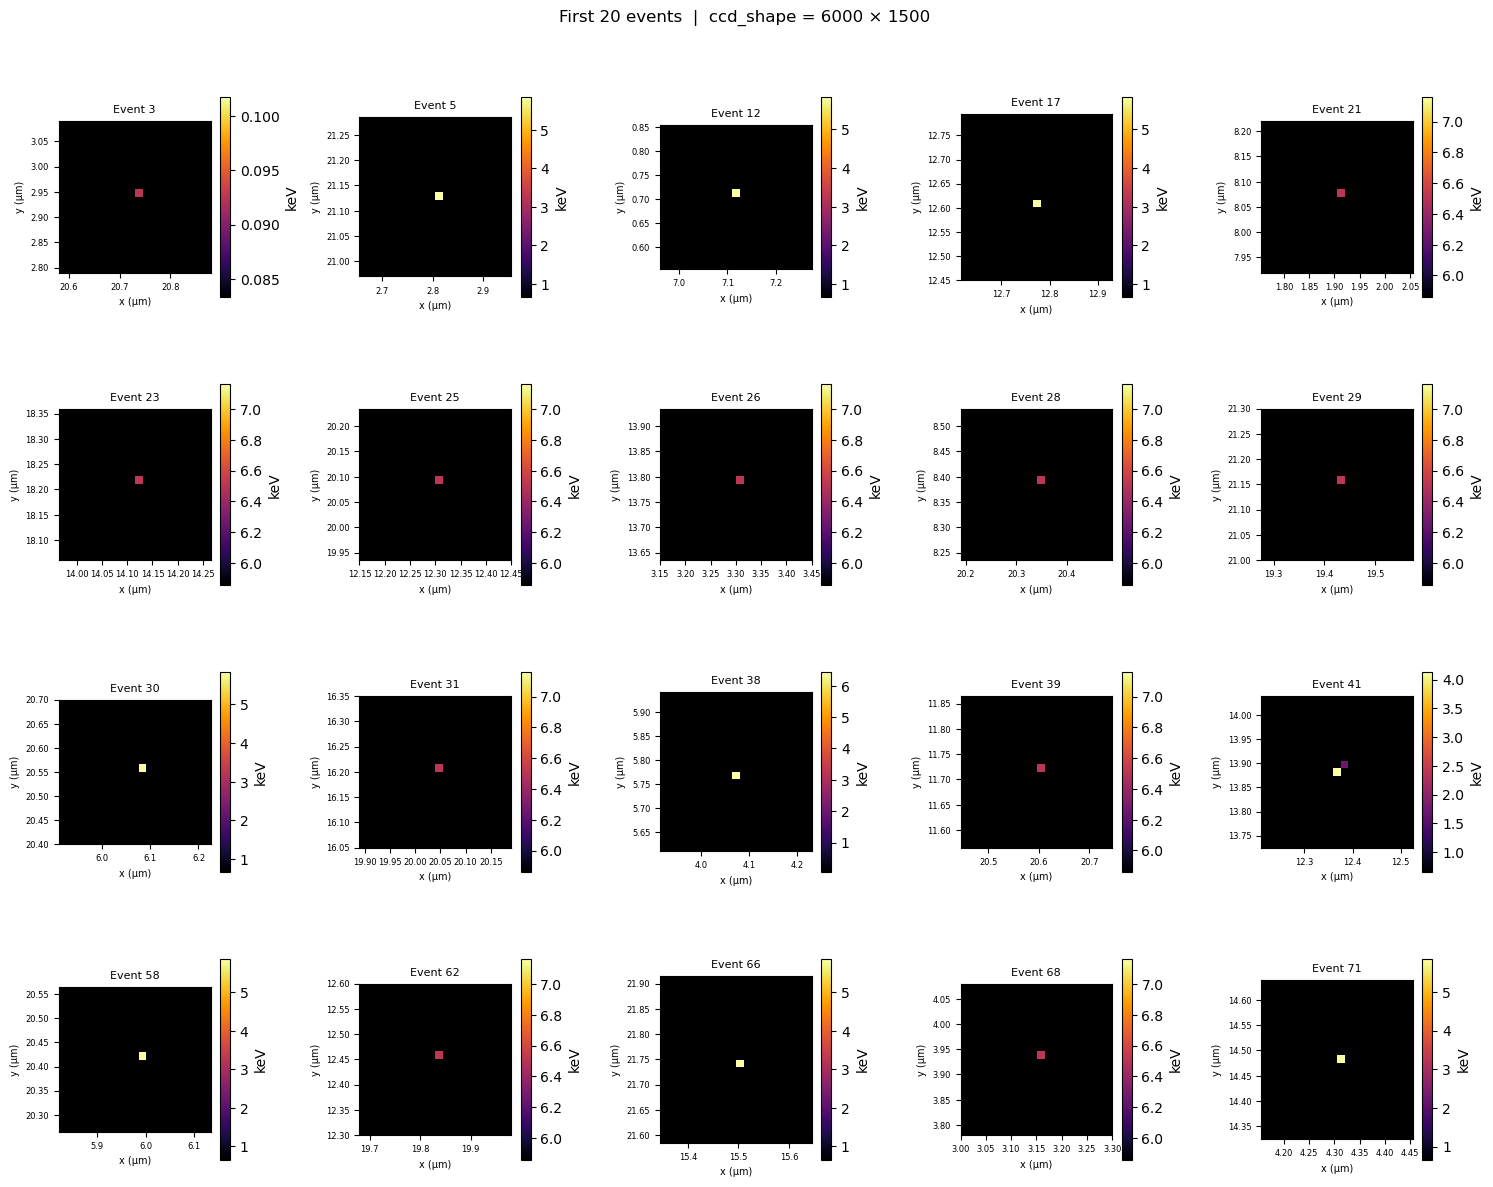

In [20]:
import math

# --- Config ---
n_events = 20       # number of events to show
cols = 5            # gallery columns
rows = math.ceil(n_events / cols)

# Determine the bounding box of each event for accurate axis labels
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

cmap = plt.cm.inferno.copy()
cmap.set_bad(color='black')

event_count = 0
entry_index = 0

while event_count < n_events and entry_index < t.GetEntries():
    t.GetEntry(entry_index)
    entry_index += 1

    current_entry_posx = t.posx
    current_entry_posy = t.posy
    current_entry_Edep = t.Edep

    if current_entry_posx.size() == 0:
        continue

    # Build a local image for this event
    image = np.zeros((ny, nx))

    xs, ys = [], []
    for j in range(current_entry_posx.size()):
        posx = current_entry_posx[j]
        posy = current_entry_posy[j]
        edep = current_entry_Edep[j]

        ix = int(posy / pixel_size)
        iy = int(posx / pixel_size)

        if 0 <= ix < ny and 0 <= iy < nx:
            image[ix, iy] += edep / 1000
            xs.append(iy)
            ys.append(ix)

    if not xs:
        continue

    # Crop to the event's bounding box with padding
    pad = 10  # pixels of padding around the event
    x_min = max(0,  min(xs) - pad)
    x_max = min(nx, max(xs) + pad)
    y_min = max(0,  min(ys) - pad)
    y_max = min(ny, max(ys) + pad)

    cropped = image[y_min:y_max, x_min:x_max]
    masked  = np.ma.masked_where(cropped == 0, cropped)

    ax = axes[event_count]
    im = ax.imshow(
        masked,
        origin='lower',
        cmap=cmap,
        aspect='equal',
        extent=[x_min * pixel_size,   # left   → real x
                x_max * pixel_size,   # right
                y_min * pixel_size,   # bottom → real y
                y_max * pixel_size],  # top
    )
    ax.set_title(f'Event {entry_index - 1}', fontsize=8)
    ax.set_xlabel('x (μm)', fontsize=7)
    ax.set_ylabel('y (μm)', fontsize=7)
    ax.tick_params(labelsize=6)
    fig.colorbar(im, ax=ax, label='keV', shrink=0.8)

    event_count += 1

# Hide any unused subplots
for k in range(event_count, len(axes)):
    axes[k].set_visible(False)

plt.suptitle(f'First {n_events} events  |  ccd_shape = 6000 × 1500', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
print(image.max())
print(image[image > 0].min())

6.511401753471424
0.06074033195091477


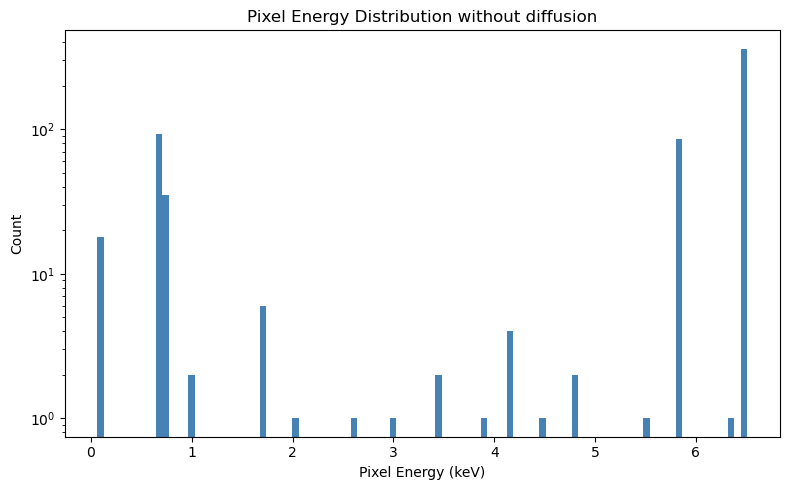

Non-zero pixels: 613
Min: 0.0608 keV
Max: 6.5113 keV
Mean: 4.8985 keV


In [93]:
# plotting a histogram with what should be the diffusion
pixel_energies = image[image > 0]

plt.figure(figsize=(8, 5))
plt.hist(pixel_energies, bins=100, color='steelblue', edgecolor='none')
plt.xlabel('Pixel Energy (keV)')
plt.ylabel('Count')
plt.title('Pixel Energy Distribution without diffusion')
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"Non-zero pixels: {len(pixel_energies)}")
print(f"Min: {pixel_energies.min():.4f} keV")
print(f"Max: {pixel_energies.max():.4f} keV")
print(f"Mean: {pixel_energies.mean():.4f} keV")
